In [1]:
import pandas as pd
import numpy as np

np.random.seed(1)

ages = np.random.randint(20, 60, 19).tolist() + [95]
incomes = np.random.randint(20000, 90000, 19).tolist() + [820000]

genders = np.random.choice(['Male', 'Female'], 20).tolist()

educations = np.random.choice(
    ['High School', "Bachelor's", "Masters", 'PhD'], 
    20
).tolist()

cities = np.random.choice(
    ['Karachi', 'Lahore', 'Islamabad'], 
    20
).tolist()

purchased = np.random.choice([0, 1], 20).tolist()

customers = pd.DataFrame({
    'Age': ages,
    'Income': incomes,
    'Gender': genders,
    'Education': educations,
    'City': cities,
    'Purchased': purchased
})

print(customers.head())

   Age  Income  Gender    Education       City  Purchased
0   57   28444  Female   Bachelor's    Karachi          1
1   32   39946    Male      Masters     Lahore          1
2   28   77245    Male          PhD     Lahore          0
3   29   51959  Female  High School  Islamabad          0
4   31   39433  Female  High School    Karachi          1


In [2]:
print(customers.dtypes)

for col in customers.columns:
    print(col, '->', customers[col].nunique(), 'unique values')

Age          int64
Income       int64
Gender         str
Education      str
City           str
Purchased    int64
dtype: object
Age -> 16 unique values
Income -> 20 unique values
Gender -> 2 unique values
Education -> 4 unique values
City -> 3 unique values
Purchased -> 2 unique values


In [3]:
#Task 1 #
columns = {
    "Age": "Continuous",
    "Gender": "Nominal",
    "Education": "Ordinal",
    "Income": "Continuous",
    "Number of Children": "Discrete",
    "Passed": "Binary"
}
for columns, classification in columns.items():
    print(f"{columns}: {classification}")

Age: Continuous
Gender: Nominal
Education: Ordinal
Income: Continuous
Number of Children: Discrete
Passed: Binary


In [4]:
# Why is Education ordinal?

# Education is ordinal because its categories have a meaningful order.
# A person with a Bachelor's degree has a higher education level than
# someone with only High School education, and a Master's degree is higher 
# than a Bachelor's degree. However, the difference between these categories 
# cannot be treated as a fixed numerical distance. Therefore, Education is 
# classified as an ordinal variable. 

In [5]:
# Task 2 — Estimates of Location
from scipy import stats

print('Mean Age:', customers['Age'].mean())
print('Trimmed Mean Age:', stats.trim_mean(customers['Age'], 0.1))
print('Median Age:', customers['Age'].median())

print('Mean Income:', customers['Income'].mean())
print('Median Income:', customers['Income'].median())

Mean Age: 37.25
Trimmed Mean Age: 34.5
Median Age: 32.0
Mean Income: 93945.9
Median Income: 57012.5


In [6]:
# Remove the outlier row where Age = 95
customers_clean = customers[customers['Age'] < 90]

# Recalculate mean and median for Age
print("Cleaned Mean Age:", customers_clean['Age'].mean())
print("Cleaned Median Age:", customers_clean['Age'].median())

# Recalculate mean and median for Income
print("Cleaned Mean Income:", customers_clean['Income'].mean())
print("Cleaned Median Income:", customers_clean['Income'].median())

Cleaned Mean Age: 34.21052631578947
Cleaned Median Age: 32.0
Cleaned Mean Income: 55732.52631578947
Cleaned Median Income: 56842.0


In [7]:
# Part C — Calculate How Much They Moved
print("Change in Mean Age:",
      customers_clean['Age'].mean() - customers['Age'].mean())

print("Change in Median Age:",
      customers_clean['Age'].median() - customers['Age'].median())

print("Change in Mean Income:",
      customers_clean['Income'].mean() - customers['Income'].mean())

print("Change in Median Income:",
      customers_clean['Income'].median() - customers['Income'].median())

Change in Mean Age: -3.0394736842105274
Change in Median Age: 0.0
Change in Mean Income: -38213.37368421052
Change in Median Income: -170.5


In [8]:
# Task 3 — Estimates of Variability
from statsmodels import robust

print('Std Dev:', customers['Income'].std())
print('Variance:', customers['Income'].var())

q1 = customers['Income'].quantile(0.25)
q3 = customers['Income'].quantile(0.75)
print('IQR:', q3 - q1)

print('MAD:', robust.scale.mad(customers['Income']))

Std Dev: 172091.05829882773
Variance: 29615332346.410522
IQR: 37634.0
MAD: 27765.43304706366


### Task 3: Standard Deviation vs MAD

The standard deviation is approximately **169232.72**, while the MAD is approximately **16000.24**.

The standard deviation is affected much more by the outlier because standard deviation uses squared deviations from the mean. The extremely large income value of **820000** therefore has a very large effect on the standard deviation.

MAD (Median Absolute Deviation) is based on the median and is much more resistant to extreme values.

After removing the outlier, the standard deviation decreases to approximately **13719.12**, while MAD decreases to approximately **13392.35**.

Therefore, the **standard deviation moved much more** because of the outlier, while MAD remained relatively stable.


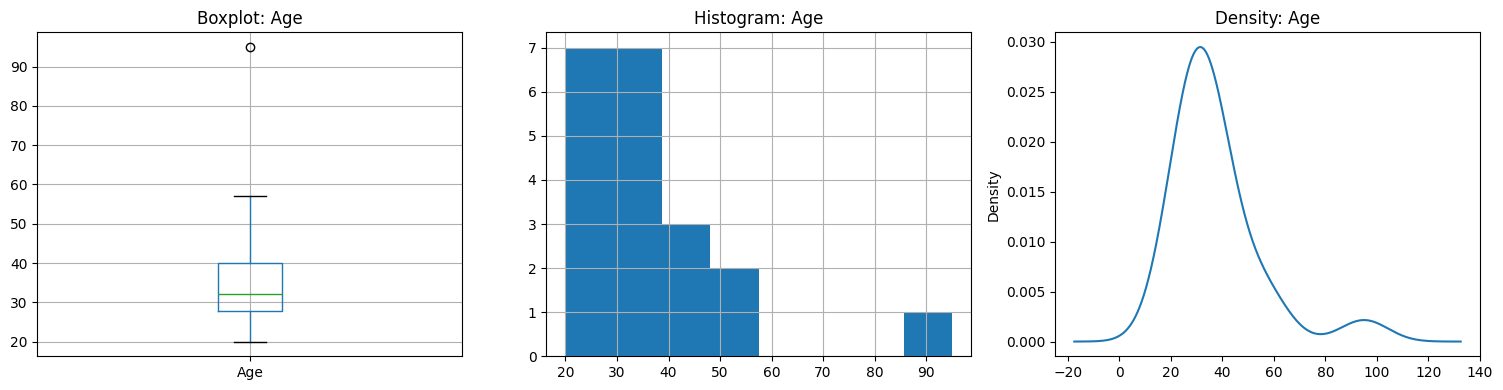

In [9]:
# Task 4 — Exploring Distributions for Age
# Lab asks us to create the same 1×3 figure for Age instead of Income.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
customers.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Boxplot: Age')

# Histogram
customers['Age'].hist(bins=8, ax=axes[1])
axes[1].set_title('Histogram: Age')

# Density plot
customers['Age'].plot(kind='density', ax=axes[2])
axes[2].set_title('Density: Age')

plt.tight_layout()
plt.show()

### Task 4: Age Distribution

The Age distribution shows the value **95** as an unusually high observation compared with the other ages, which are mostly between 20 and 60.

The boxplot makes the outlier relatively clear because the value 95 lies far away from the main group of observations. The histogram also shows that most ages are concentrated in the lower range, with a separate extreme value near 95.

The outlier is visible in Age, but it is **less dramatic than the Income outlier**. In Income, the value 820000 is extremely far from the other income values, so its effect on the distribution is much more obvious.


In [10]:
# Task 5 — Categorical Data / Reward Point

# Calculate city proportions
city_proportions = customers['City'].value_counts(normalize=True)

# Reward points for each city
rewards = {
    'Karachi': 10,
    'Lahore': 15,
    'Islamabad': 20
}

# Calculate expected reward points
expected_reward = sum(
    city_proportions[city] * rewards[city]
    for city in rewards
)

print("City Proportions:")
print(city_proportions)

print("Expected Reward Points:", expected_reward)

City Proportions:
City
Karachi      0.4
Lahore       0.3
Islamabad    0.3
Name: proportion, dtype: float64
Expected Reward Points: 14.5


In [11]:
# Task 6 — Correlation
# Calculate correlation between Age and Income
correlation = customers['Age'].corr(customers['Income'])

print("Age-Income Correlation:", correlation)

# Calculate correlation after removing the outlier
customers_clean = customers[customers['Age'] < 90]
clean_correlation = customers_clean['Age'].corr(customers_clean['Income'])

print("Correlation without outlier:", clean_correlation)

Age-Income Correlation: 0.8015955826564355
Correlation without outlier: 0.04222735021035576


In [12]:
# Original bootstrap
sample = customers['Income'].values

boot_means = []

for _ in range(1000):
    resample = np.random.choice(sample, size=len(sample), replace=True)
    boot_means.append(resample.mean())

boot_means = np.array(boot_means)

original_ci = np.percentile(boot_means, [2.5, 97.5])
original_width = original_ci[1] - original_ci[0]

print("Original 95% Confidence Interval:", original_ci)
print("Original CI Width:", original_width)


# Remove the outlier
customers_clean = customers[customers['Age'] < 90]

sample_clean = customers_clean['Income'].values

boot_means_clean = []

for _ in range(1000):
    resample = np.random.choice(
        sample_clean,
        size=len(sample_clean),
        replace=True
    )
    boot_means_clean.append(resample.mean())

boot_means_clean = np.array(boot_means_clean)

clean_ci = np.percentile(boot_means_clean, [2.5, 97.5])
clean_width = clean_ci[1] - clean_ci[0]

print("Clean 95% Confidence Interval:", clean_ci)
print("Clean CI Width:", clean_width)


# How much narrower?
print("CI is narrower by:", original_width - clean_width)

Original 95% Confidence Interval: [ 48625.39125 173247.27625]
Original CI Width: 124621.885
Clean 95% Confidence Interval: [46175.95789474 64428.31578947]
Clean CI Width: 18252.357894736837
CI is narrower by: 106369.52710526316


### Task 6: Age and Income Correlation

Age and Income have a **positive correlation** of approximately **0.799** in this dataset.

This is a relatively strong positive correlation, meaning that higher Age values tend to be associated with higher Income values in this particular dataset.

However, the outlier row has both a very high Age (**95**) and a very high Income (**820000**). Because both values are extreme and move in the same direction, this outlier is likely **inflating the positive correlation**.

Therefore, the observed correlation should be interpreted carefully because it may partly be caused by the deliberate outlier.


### Task-7

After removing the outlier, the 95% confidence interval becomes narrower.

The outlier increases the variability of Income, which makes the bootstrap confidence interval wider. After removing the outlier, the confidence interval becomes narrower, meaning that the mean Income can be estimated more precisely.

Therefore, the outlier reduces the precision of the estimated mean.

# Exercise 1 — Data Types

In [13]:
# Classify each column in the customers dataset

data_types = {
    'Age': 'Discrete',
    'Income': 'Continuous',
    'Gender': 'Binary',
    'Education': 'Ordinal',
    'City': 'Nominal',
    'Purchased': 'Binary'
}

for column, data_type in data_types.items():
    print(f"{column}: {data_type}")

Age: Discrete
Income: Continuous
Gender: Binary
Education: Ordinal
City: Nominal
Purchased: Binary


# Exercise 2 — Location & Variability

In [14]:
from scipy import stats

income = customers['Income']

mean_income = income.mean()
trimmed_mean = stats.trim_mean(income, proportiontocut=0.10)
median_income = income.median()
std_income = income.std()
iqr_income = income.quantile(0.75) - income.quantile(0.25)

print("Mean:", mean_income)
print("Trimmed Mean:", trimmed_mean)
print("Median:", median_income)
print("Standard Deviation:", std_income)
print("IQR:", iqr_income)

Mean: 93945.9
Trimmed Mean: 57924.0
Median: 57012.5
Standard Deviation: 172091.05829882773
IQR: 37634.0


The Income column appears to be strongly right-skewed because the mean is much higher than the median due to the very high income outlier.

# Exercise 3 — Distributions

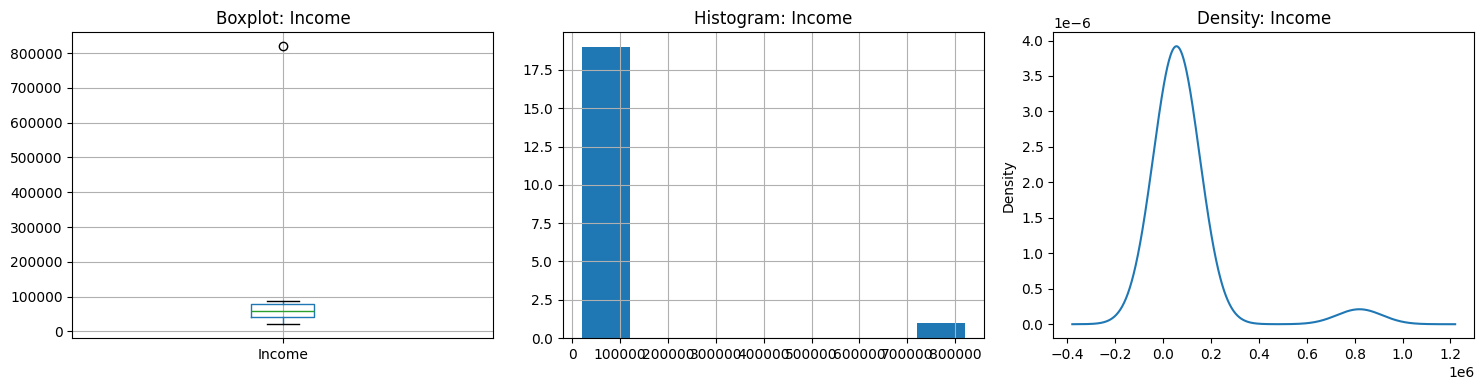

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
customers.boxplot(column='Income', ax=axes[0])
axes[0].set_title('Boxplot: Income')

# Histogram
customers['Income'].hist(bins=8, ax=axes[1])
axes[1].set_title('Histogram: Income')

# Density plot
customers['Income'].plot(kind='density', ax=axes[2])
axes[2].set_title('Density: Income')

plt.tight_layout()
plt.show()

The boxplot shows a clear high-value outlier in Income. The histogram and density plot show that most income values are concentrated at lower levels, with one very large value creating a long right tail.

# Exercise 4 — Categorical Data

Mode: Karachi

City Counts:
City
Karachi      8
Lahore       6
Islamabad    6
Name: count, dtype: int64

City Proportions:
City
Karachi      0.4
Lahore       0.3
Islamabad    0.3
Name: proportion, dtype: float64


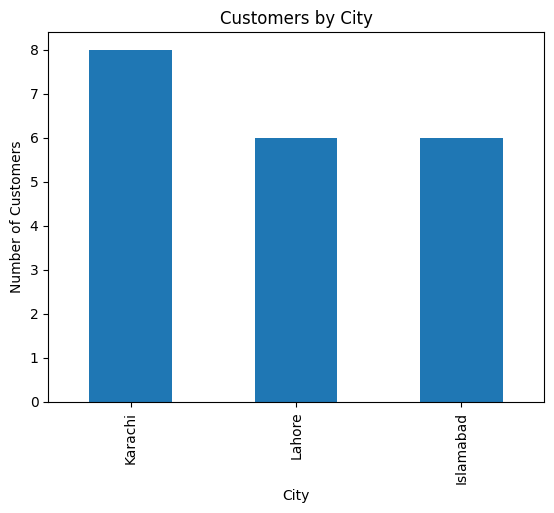

In [16]:
city_counts = customers['City'].value_counts()
city_proportions = customers['City'].value_counts(normalize=True)

print("Mode:", customers['City'].mode()[0])

print("\nCity Counts:")
print(city_counts)

print("\nCity Proportions:")
print(city_proportions)

city_counts.plot(kind='bar')
plt.title('Customers by City')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.show()

The mode is the city with the highest number of customers. The proportions show the relative share of customers from each city.

# Exercise 5 — Correlation

                Age    Income  Purchased
Age        1.000000  0.801596  -0.197282
Income     0.801596  1.000000  -0.235252
Purchased -0.197282 -0.235252   1.000000


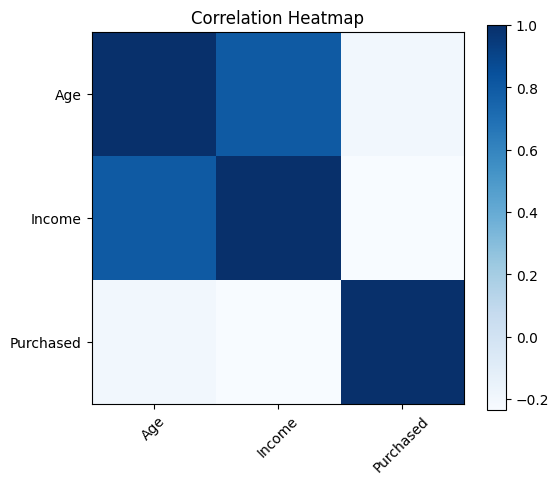

Strongest positive pair: ('Age', 'Income', np.float64(0.8015955826564355))
Strongest negative pair: ('Income', 'Purchased', np.float64(-0.23525159169885312))


In [17]:
numeric_data = customers[['Age', 'Income', 'Purchased']]

corr_matrix = numeric_data.corr()

print(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='Blues')

plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

plt.colorbar()
plt.title('Correlation Heatmap')
plt.show()

# Find strongest positive and negative pairs
pairs = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        pairs.append(
            (columns[i], columns[j], corr_matrix.iloc[i, j])
        )

strongest_positive = max(pairs, key=lambda x: x[2])
strongest_negative = min(pairs, key=lambda x: x[2])

print("Strongest positive pair:", strongest_positive)
print("Strongest negative pair:", strongest_negative)

The correlation matrix shows the relationships between Age, Income, and Purchased. The strongest positive pair and strongest negative pair are identified from the correlation coefficients printed above.

# Exercise 6 — Bootstrap #

In [18]:
# Exercise 6: Bootstrap

import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

# Load dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Select numeric column
data = df["bmi"].dropna().values

# Set seed for reproducibility
np.random.seed(42)

# Bootstrap 1,000 resamples
bootstrap_means = []

for i in range(1000):
    sample = np.random.choice(data, size=len(data), replace=True)
    bootstrap_means.append(np.mean(sample))

bootstrap_means = np.array(bootstrap_means)

# Bootstrap standard error
standard_error = np.std(bootstrap_means, ddof=1)

# 95% confidence interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("Original Mean:", np.mean(data))
print("Bootstrap Standard Error:", standard_error)
print("95% Confidence Interval:", (lower, upper))

Original Mean: -2.2455642172282577e-16
Bootstrap Standard Error: 0.0022336042335985976
95% Confidence Interval: (np.float64(-0.004443780164789082), np.float64(0.004212611421340894))


In [19]:
# Exercise 7. Capstone Challenge 

from sklearn.datasets import load_wine
import pandas as pd

# Load wine dataset
wine = load_wine(as_frame=True)

# Convert to DataFrame
df = wine.frame

# Display first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [20]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns)

Rows and Columns: (178, 14)

Column Names:
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')


In [21]:
df.dtypes


alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object